<h2>Analyse exploratoire des donnees</h2>


In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd   #lire fichiers csv
import matplotlib.pyplot as plt


%matplotlib inline

In [3]:
from pathlib import Path

print("Current directory :", Path.cwd())
print("Parent :", Path.cwd().parent)
print("Grandparent :", Path.cwd().parent.parent)

Current directory : c:\Users\hello2\Downloads\tool-wear-detection\ai\notebooks
Parent : c:\Users\hello2\Downloads\tool-wear-detection\ai
Grandparent : c:\Users\hello2\Downloads\tool-wear-detection


In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent

DATASET_PATH = PROJECT_ROOT / "dataset"
IMAGE_FOLDER = DATASET_PATH / "tool"
CSV_FOLDER = DATASET_PATH / "tool_distribution"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_PATH :", DATASET_PATH)
print("IMAGE_FOLDER exists :", IMAGE_FOLDER.exists())
print("CSV_FOLDER exists :", CSV_FOLDER.exists())

print("\nContenu de tool_distribution :")
for file in CSV_FOLDER.iterdir():
    print(file.name)

PROJECT_ROOT : c:\Users\hello2\Downloads\tool-wear-detection
DATASET_PATH : c:\Users\hello2\Downloads\tool-wear-detection\dataset
IMAGE_FOLDER exists : True
CSV_FOLDER exists : True

Contenu de tool_distribution :
test.csv
train.csv
val.csv


In [5]:
train_df = pd.read_csv(CSV_FOLDER / "train.csv")
val_df = pd.read_csv(CSV_FOLDER / "val.csv")
test_df = pd.read_csv(CSV_FOLDER / "test.csv")

print(train_df.head())

       id image_label  tool_label
0  T1R2B1       sharp           1
1  T1R2B2       sharp           1
2  T1R2B3       sharp           1
3  T1R2B4       sharp           1
4  T1R3B1       sharp           1


<h3>Informations générales</h3>

In [6]:
print("Train :", train_df.shape)
print("Validation :", val_df.shape)
print("Test :", test_df.shape)

Train : (2424, 3)
Validation : (52, 3)
Test : (56, 3)


<h3>Informations détaillées</h3>

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2424 entries, 0 to 2423
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           2424 non-null   object
 1   image_label  2424 non-null   object
 2   tool_label   2424 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 56.9+ KB


<h3>Vérifier les valeurs manquantes</h3>

In [8]:
train_df.isnull().sum()

id             0
image_label    0
tool_label     0
dtype: int64

<h3>Distribution des classes</h3>

In [9]:
train_df["image_label"].value_counts()

image_label
sharp     882
dulled    798
used      744
Name: count, dtype: int64

<h3>Affichage graphique</h3>

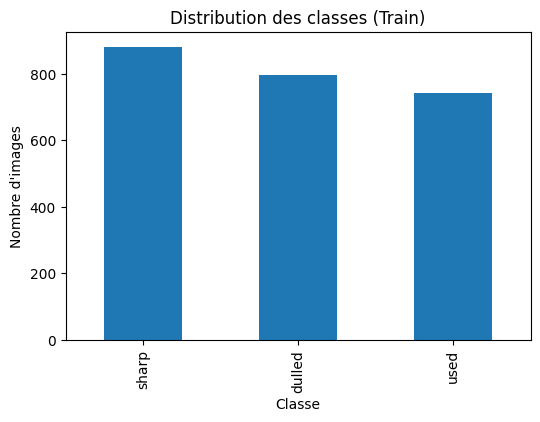

In [10]:
import matplotlib.pyplot as plt

train_df["image_label"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution des classes (Train)"
)

plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.show()

<h3>Question 1 : Combien d'images contient le dataset ?</h3>

In [11]:
# Nombre d'images dans chaque ensemble

nb_train = len(train_df)
nb_val = len(val_df)
nb_test = len(test_df)

# Nombre total d'images

nb_total = nb_train + nb_val + nb_test

print(f"Train      : {nb_train}")
print(f"Validation : {nb_val}")
print(f"Test       : {nb_test}")
print("-" * 30)
print(f"Total      : {nb_total}")

Train      : 2424
Validation : 52
Test       : 56
------------------------------
Total      : 2532


<h5>Le jeu de données utilisé dans ce projet contient un total de 2532 images, réparties en trois ensembles : 2424 images pour l'entraînement, 52 images pour la validation et 56 images pour le test. Cette répartition permet d'entraîner le modèle, de suivre ses performances pendant l'apprentissage et d'évaluer sa capacité de généralisation sur des données non utilisées lors de l'entraînement.</h5>

In [12]:
import os

# Nombre de fichiers dans le dossier tool
files = os.listdir(IMAGE_FOLDER)

print("Nombre total d'éléments :", len(files))

# Afficher les 10 premiers fichiers
print(files[:10])

Nombre total d'éléments : 3072
['AugT10R10B10.jpg', 'AugT10R10B11.jpg', 'AugT10R10B12.jpg', 'AugT10R10B13.jpg', 'AugT10R10B14.jpg', 'AugT10R10B20.jpg', 'AugT10R10B21.jpg', 'AugT10R10B22.jpg', 'AugT10R10B23.jpg', 'AugT10R10B24.jpg']


In [ ]:
from collections import Counter
import os

extensions = Counter()

for file in os.listdir(IMAGE_FOLDER):
    ext = os.path.splitext(file)[1].lower()
    extensions[ext] += 1

print(extensions)

Counter({'.jpg': 3072})


In [14]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2424, 3)
(52, 3)
(56, 3)


In [ ]:
#

aug_images = [f for f in files if f.startswith("Aug")]

print("Nombre d'images augmentées :", len(aug_images))

Nombre d'images augmentées : 2560


In [16]:
print(aug_images[:10])

['AugT10R10B10.jpg', 'AugT10R10B11.jpg', 'AugT10R10B12.jpg', 'AugT10R10B13.jpg', 'AugT10R10B14.jpg', 'AugT10R10B20.jpg', 'AugT10R10B21.jpg', 'AugT10R10B22.jpg', 'AugT10R10B23.jpg', 'AugT10R10B24.jpg']


In [ ]:
#tous les noms des images
folder_ids = {f.replace(".jpg", "") for f in files}

#
csv_ids = set(train_df["id"]) | set(val_df["id"]) | set(test_df["id"])

#
missing_in_csv = folder_ids - csv_ids

print("Nombre d'images absentes du CSV :", len(missing_in_csv))

#
print(sorted(list(missing_in_csv))[:20])

Nombre d'images absentes du CSV : 540
['AugT10R10B10', 'AugT10R10B11', 'AugT10R10B12', 'AugT10R10B13', 'AugT10R10B14', 'AugT10R10B20', 'AugT10R10B21', 'AugT10R10B22', 'AugT10R10B23', 'AugT10R10B24', 'AugT10R10B30', 'AugT10R10B31', 'AugT10R10B32', 'AugT10R10B33', 'AugT10R10B34', 'AugT10R10B40', 'AugT10R10B41', 'AugT10R10B42', 'AugT10R10B43', 'AugT10R10B44']


<h5>Le dossier des images contient 3072 fichiers. Cependant, seuls 2532 images sont référencées dans les fichiers de répartition (train.csv, val.csv et test.csv) et utilisées dans ce projet. Les autres images correspondent à des images augmentées qui ne sont pas incluses dans l'ensemble d'entraînement fourni</h5>

<h3>Quelles sont les classes présentes?</h3>

In [23]:
classes = train_df["image_label"].unique()
print("Classes presentes :",classes)

Classes presentes : ['sharp' 'used' 'dulled']


<h5>L'analyse du jeu de données montre qu'il est composé de trois classes représentant les différents états d'usure des outils industriels : Sharp, Used et Dulled. Ces trois catégories seront utilisées pour entraîner le modèle de classification.</h5>

<h3>Combien d'images existe-t-il dans chaque classe ?
</h3>

In [25]:
class_counts = train_df["image_label"].value_counts()
print(class_counts)

image_label
sharp     882
dulled    798
used      744
Name: count, dtype: int64


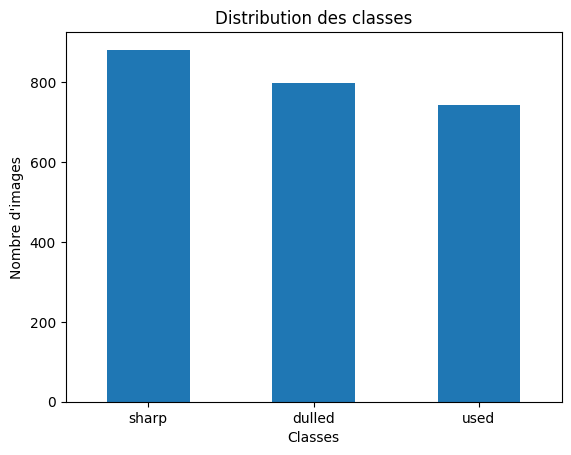

In [26]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Distribution des classes")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.xticks(rotation=0)

plt.show()

In [27]:
(class_counts / class_counts.sum() * 100).round(2)

image_label
sharp     36.39
dulled    32.92
used      30.69
Name: count, dtype: float64

<h5>La répartition des images montre le nombre d'exemples disponibles pour chacune des trois classes. Cette analyse permet de vérifier si le jeu de données est équilibré avant l'entraînement du modèle.</h5>

<h3>Les classes sont-elles équilibrées ?</h3>

<h5>L'analyse de la répartition des classes montre que l'ensemble d'entraînement contient 882 images de la classe Sharp, 798 images de la classe Dulled et 744 images de la classe Used. Les proportions des trois classes sont relativement proches (36,39 %, 32,92 % et 30,69 %), ce qui indique que le jeu de données est globalement équilibré. Cette répartition est favorable à l'entraînement d'un modèle de classification, car elle limite le risque de biais envers une classe particulière</h5>

<h3>Quelles sont les dimensions minimales et maximales des images ?</h3>

In [ ]:
import cv2
from pathlib import Path

widths = []
heights = []

all_ids = pd.concat([train_df["id"], val_df["id"], test_df["id"]])

for image_id in all_ids:
    image_path = IMAGE_FOLDER / f"{image_id}.jpg"

    image = cv2.imread(str(image_path))

    if image is not None:
        h, w = image.shape[:2]
        widths.append(w)
        heights.append(h)

print("Nombre d'images analysées :", len(widths))
print()

print(f"Largeur minimale  : {min(widths)} px")
print(f"Largeur maximale  : {max(widths)} px")

print()

print(f"Hauteur minimale  : {min(heights)} px")
print(f"Hauteur maximale  : {max(heights)} px")

Nombre d'images analysées : 2532

Largeur minimale  : 310 px
Largeur maximale  : 3101 px

Hauteur minimale  : 100 px
Hauteur maximale  : 1001 px


In [29]:
import pandas as pd

dimensions = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

dimensions.describe()

,Width,Height
count,2532.000000,2532.000000
mean,1633.178120,515.700237
std,659.242837,222.307869
min,310.000000,100.000000
25%,1159.000000,373.750000
50%,1550.000000,500.000000
75%,1550.000000,500.000000
max,3101.000000,1001.000000


(array([  68.,   82.,   79.,  494., 1414.,   10.,   10.,    6.,    9.,
         360.]),
 array([ 310. ,  589.1,  868.2, 1147.3, 1426.4, 1705.5, 1984.6, 2263.7,
        2542.8, 2821.9, 3101. ]),
 <BarContainer object of 10 artists>)

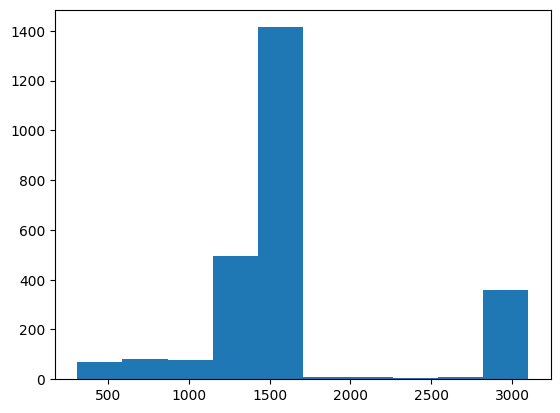

In [30]:
plt.hist(widths)

<h5>L'analyse des dimensions montre que les images du jeu de données ne possèdent pas une taille uniforme. La largeur varie entre 310 px et 3101 px, tandis que la hauteur varie entre 100 px et 1001 px. Cette variabilité rend nécessaire une étape de redimensionnement afin d'obtenir des images de dimensions homogènes avant l'entraînement du modèle. Dans ce projet, les images seront redimensionnées à 224 × 224 pixels.</h5>

<h3>Toutes les images sont-elles valides ?</h3>

In [31]:
#verification des images
import cv2
invalid_images = []
#regroupr les images qui utilse dans projet
all_ids = pd.concat([train_df["id"], val_df["id"], test_df["id"]])

for image_id in all_ids:
    image_path = IMAGE_FOLDER / f"{image_id}.jpg"

    image = cv2.imread(str(image_path))

    if image is None:
        invalid_images.append(image_id)

print("Nombre d'images invalides :", len(invalid_images))

Nombre d'images invalides : 0


<h5>Une vérification de l'intégrité des images a été réalisée à l'aide de la bibliothèque OpenCV. Les résultats montrent que toutes les images utilisées dans le projet sont valides et peuvent être lues correctement, ce qui garantit la qualité du jeu de données avant l'entraînement du modèle.</h5>

<h3>Existe-t-il des images dupliquées ?</h3>

In [33]:
import hashlib
#md5 compare contenu pas nom

hashes = {}
duplicates = []

all_ids = pd.concat([train_df["id"], val_df["id"], test_df["id"]])

for image_id in all_ids:
    image_path = IMAGE_FOLDER / f"{image_id}.jpg"

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    if file_hash in hashes:
        duplicates.append((hashes[file_hash], image_id))
    else:
        hashes[file_hash] = image_id

print("Nombre d'images dupliquées :", len(duplicates))



Nombre d'images dupliquées : 0


<h5>Une vérification des images dupliquées a été réalisée en utilisant un algorithme de hachage (MD5). Les résultats montrent qu'aucune image dupliquée n'a été détectée dans le jeu de données utilisé, ce qui garantit une meilleure qualité des données pour l'entraînement du modèle</h5>

<h3>Visualisation des donnees</h3>

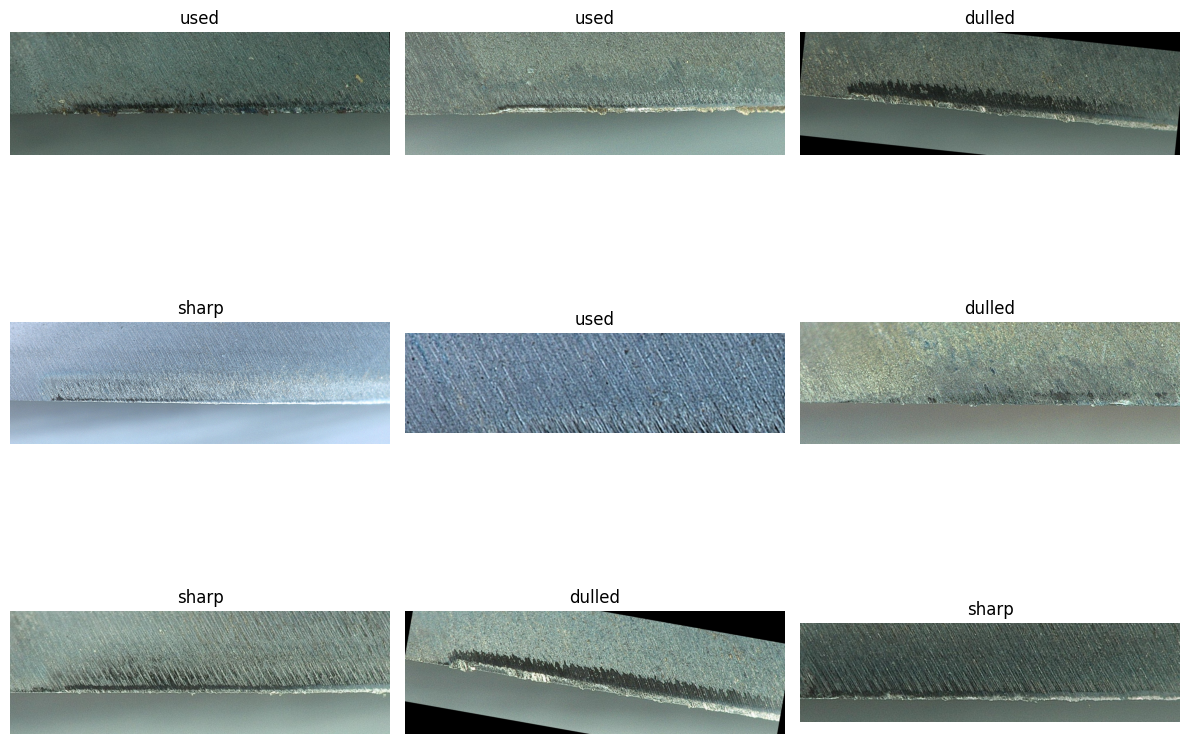

In [34]:
import matplotlib.pyplot as plt
import cv2

# Sélection aléatoire de 9 images
sample = train_df.sample(n=9, random_state=42)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(sample.iterrows()):
    image_path = IMAGE_FOLDER / f"{row['id']}.jpg"

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"{row['image_label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<h5>Afin d'obtenir une première vue d'ensemble du jeu de données, un échantillon d'images a été visualisé. Les exemples présentés appartiennent aux trois classes du dataset : Sharp, Used et Dulled. Cette visualisation permet d'observer les différences entre les niveaux d'usure des outils ainsi que la diversité des images en termes d'orientation, de luminosité et de résolution.

Analyse

L'observation des images montre que les labels sont cohérents avec l'état apparent des outils. Les outils classés Sharp présentent un tranchant peu usé, ceux de la classe Used montrent un niveau d'usure intermédiaire, tandis que les outils de la classe Dulled présentent une usure plus importante. Cette cohérence constitue un élément important pour garantir la qualité des données utilisées lors de l'entraînement du modèle
(La visualisation d'un échantillon d'images montre que le jeu de données présente une diversité satisfaisante. Les images diffèrent par leur angle de prise de vue, leur niveau d'usure, leur luminosité ainsi que leurs dimensions. Cette diversité est importante pour entraîner un modèle capable de généraliser sur de nouvelles images)</h5>